# Train the models

Trains phishing classifiers on the cleaned GENERAL data and saves the best one.

What happens:
  1. Load phishing_general_clean.csv (the training data from notebook 03)
  2. Write a small helper file (features.py) that turns raw email text into
     the numbers the model needs. The app will import this same file later,
     so the model is always fed exactly what it was trained on.
  3. Build two feature sets:
       A. TF-IDF only          - word patterns in the text
       B. TF-IDF + structural  - same, plus counts of links, urgent words,
                                 capital letters, etc.
  4. Train three models on each: Logistic Regression, Random Forest, SVM
  5. Compare all six with 5-fold cross-validation (recall, precision, F1, AUC)
  6. Take the best one, fit it on all the training data, calibrate its
     probabilities so the percentage output is trustworthy, and save it.




In [4]:
# Connect to Drive and load the training data
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd

project = "/content/drive/MyDrive/Colab Notebooks/Master's project"
data_folder = os.path.join(project, "Data")
model_folder = os.path.join(project, "Model")
os.makedirs(model_folder, exist_ok=True)

train = pd.read_csv(os.path.join(data_folder, "phishing_general_clean.csv"))
train["text"] = train["text"].fillna("").astype(str)
train["text_clean"] = train["text_clean"].fillna("").astype(str)

print("Training rows:", len(train))
print("\nLabel balance (0 = legitimate, 1 = phishing):")
print(train["label"].value_counts())

Mounted at /content/drive
Training rows: 86809

Label balance (0 = legitimate, 1 = phishing):
label
1    43981
0    42828
Name: count, dtype: int64


In [5]:
#  Write the feature helper file (features.py)
# This cell SAVES a Python file into the Model folder. It holds two things:
#   - clean_text(): the same cleaning steps as notebook 03
#   - structural_features(): counts things like links, urgent words and capital letters in the ORIGINAL (uncleaned) email

# Keeping this in one file means the app and the notebooks always agree on how an email is turned into numbers.
# (The %%writefile line at the top tells Colab to save the cell as a file instead of running it.)

%%writefile "/content/drive/MyDrive/Colab Notebooks/Master's project/Model/features.py"
"""features.py - turns raw email text into the inputs the phishing model needs.

Used by notebook 04 (training_models), notebook 05 (evaluation) and the tool.
"""
import re
import pandas as pd

# ---- words that suggest urgency, credential requests, or money -------------
# These lists come from NCSC guidance on recognising phishing and from the
# literature review. They are counted, not removed.
URGENCY_WORDS = [
    "urgent", "urgently", "immediately", "immediate", "now", "asap", "expire", "expires",
    "expired", "expiring", "suspended", "suspend", "deadline", "final notice", "last chance",
    "within 24 hours", "within 48 hours", "action required", "act now", "warning", "alert",
    "limited time", "today only", "failure to", "will be closed", "will be locked",
]
CREDENTIAL_WORDS = [
    "password", "passcode", "login", "log in", "sign in", "username", "verify", "verification",
    "confirm", "confirmation", "authenticate", "credentials", "account", "security",
    "update your", "validate", "re-activate", "reactivate", "unlock", "mailbox", "quota",
]
MONEY_WORDS = [
    "payment", "invoice", "bank", "transfer", "refund", "£", "$", "€", "usd", "gbp",
    "fund", "funds", "wire", "bitcoin", "gift card", "voucher", "salary", "payroll",
    "tax", "hmrc", "paypal", "purchase", "order", "prize", "lottery", "won",
]

def _count_any(text_lower, words):
    """How many times any of the words appear in the text."""
    return sum(text_lower.count(w) for w in words)


def clean_text(text):
    """Same cleaning as notebook 03, so the model sees the same style of text."""
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)                                   # HTML tags
    text = re.sub(r"^(message-id|x-[\w-]+|received|content-type|content-transfer-encoding|"
                  r"mime-version|return-path|delivered-to|list-id|precedence|in-reply-to|"
                  r"references|sender|reply-to|date|to|cc|bcc|from):.*$",
                  " ", text, flags=re.IGNORECASE | re.MULTILINE)           # header lines
    text = re.sub(r"(https?://\S+|www\.\S+)", " URL ", text)               # links
    text = re.sub(r"\S+@\S+", " EMAIL ", text)                             # email addresses
    text = re.sub(r"\d{5,}", " NUMBER ", text)                             # long numbers
    text = re.sub(r"\b(19[9]\d|20[0-2]\d)\b", " YEAR ", text)              # years
    text = re.sub(r"[^\w\s!?$%£€.,:;'\"()\-]", " ", text)                  # odd characters
    text = re.sub(r"\s+", " ", text).strip()
    return text


def structural_features(text):
    """Counts and ratios from the ORIGINAL email text. Returns a dictionary."""
    text = str(text)
    lower = text.lower()
    letters = [c for c in text if c.isalpha()]
    n_letters = max(len(letters), 1)                  # max(...,1) avoids dividing by zero
    words = text.split()
    n_words = max(len(words), 1)

    urls = re.findall(r"(https?://\S+|www\.\S+)", text)
    return {
        "n_chars":        len(text),
        "n_words":        len(words),
        "n_urls":         len(urls),
        "n_emails":       len(re.findall(r"\S+@\S+", text)),
        "n_exclaim":      text.count("!"),
        "n_question":     text.count("?"),
        "caps_ratio":     sum(1 for c in letters if c.isupper()) / n_letters,
        "digit_ratio":    sum(1 for c in text if c.isdigit()) / max(len(text), 1),
        "n_urgency":      _count_any(lower, URGENCY_WORDS),
        "n_credential":   _count_any(lower, CREDENTIAL_WORDS),
        "n_money":        _count_any(lower, MONEY_WORDS),
        "has_ip_url":     int(bool(re.search(r"https?://\d{1,3}(\.\d{1,3}){3}", text))),
        "avg_word_len":   sum(len(w) for w in words) / n_words,
    }

STRUCTURAL_COLUMNS = list(structural_features("example").keys())


def make_frame(raw_texts, clean_texts=None):
    """Build the table the model expects: one 'text_clean' column plus the
    structural feature columns. If clean_texts is not given, clean_text() is used."""
    raw_texts = list(raw_texts)
    if clean_texts is None:
        clean_texts = [clean_text(t) for t in raw_texts]
    frame = pd.DataFrame([structural_features(t) for t in raw_texts])
    frame.insert(0, "text_clean", list(clean_texts))
    return frame

Overwriting /content/drive/MyDrive/Colab Notebooks/Master's project/Model/features.py


In [6]:
# Import the helper file and build the feature table
# I use the text_clean column saved by notebook 03 (it also has the give-away words removed) and compute structural features from the original text.

import sys
sys.path.append(model_folder)          # tell Python where features.py lives
import importlib, features
importlib.reload(features)             # make sure the latest version is loaded

X = features.make_frame(train["text"], clean_texts=train["text_clean"])
y = train["label"].values

print("Feature table shape:", X.shape)
print("\nStructural feature averages, phishing vs legitimate:")
print(X[features.STRUCTURAL_COLUMNS].groupby(y).mean().round(2).T)

Feature table shape: (86809, 14)

Structural feature averages, phishing vs legitimate:
                    0        1
n_chars       2026.97  1146.30
n_words        334.79   178.94
n_urls           1.63     0.39
n_emails         0.77     1.23
n_exclaim        0.96     1.46
n_question       1.72     1.05
caps_ratio       0.04     0.06
digit_ratio      0.03     0.02
n_urgency        1.20     1.43
n_credential     0.50     1.21
n_money          1.87     2.39
has_ip_url       0.00     0.00
avg_word_len     4.95     5.96


In [8]:
# Define the two feature set "recipes"
# A ColumnTransformer applies different processing to different columns:
#   - text_clean  -> TF-IDF (turns words into numbers, 1-word and 2-word phrases)
#   - structural  -> scaled to 0-1 so big counts don't swamp small ratios
# Feature set A uses only the first; feature set B uses both.

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

def tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), max_features=30000, min_df=3,
                           sublinear_tf=True, stop_words="english")

feature_sets = {
    "A: TF-IDF only": lambda: ColumnTransformer([
        ("tfidf", tfidf(), "text_clean"),
    ]),
    "B: TF-IDF + structural": lambda: ColumnTransformer([
        ("tfidf", tfidf(), "text_clean"),
        ("struct", MinMaxScaler(), features.STRUCTURAL_COLUMNS),
    ]),
}

In [9]:
# Define the three models
# class_weight="balanced" tells each model to care equally about both classes even if one is more common. random_state makes results repeatable.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=2000, C=1.0,
                                                      class_weight="balanced", random_state=42),
    "Random Forest":       lambda: RandomForestClassifier(n_estimators=200, max_features="sqrt",
                                                          class_weight="balanced", n_jobs=-1,
                                                          random_state=42),
    "SVM (linear)":        lambda: LinearSVC(C=0.5, class_weight="balanced", random_state=42),
}


In [ ]:
# Set up 5-fold cross-validation
# The data is split into 5 parts. Each model is trained on 4 parts and tested on the 5th, five times, so every email is tested exactly once.
# I report the average of the five scores. "Stratified" keeps the phishing/legitimate balance the same in every part.
# I record recall, precision, F1 and AUC - not just accuracy - because missing a phishing email (low recall) is the costly mistake in a school.

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"recall": "recall", "precision": "precision", "f1": "f1", "auc": "roc_auc"}

In [ ]:
# Run all six combinations (this took ages)

import time
results = []

for fs_name, make_features in feature_sets.items():
    for model_name, make_model in models.items():
        t0 = time.time()
        pipe = Pipeline([("features", make_features()), ("model", make_model())])
        scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=1)
        row = {"feature_set": fs_name, "model": model_name,
               "recall":    scores["test_recall"].mean(),
               "precision": scores["test_precision"].mean(),
               "f1":        scores["test_f1"].mean(),
               "auc":       scores["test_auc"].mean(),
               "f1_std":    scores["test_f1"].std(),          # how much F1 varied between folds
               "minutes":   (time.time() - t0) / 60}
        results.append(row)
        print(f"{fs_name:25s} | {model_name:20s} | F1 {row['f1']:.3f} | recall {row['recall']:.3f} "
              f"| AUC {row['auc']:.3f} | {row['minutes']:.1f} min")

results = pd.DataFrame(results)

A: TF-IDF only            | Logistic Regression  | F1 0.985 | recall 0.986 | AUC 0.999 | 5.5 min
A: TF-IDF only            | Random Forest        | F1 0.982 | recall 0.977 | AUC 0.998 | 30.8 min
A: TF-IDF only            | SVM (linear)         | F1 0.989 | recall 0.990 | AUC 0.999 | 4.5 min
B: TF-IDF + structural    | Logistic Regression  | F1 0.985 | recall 0.986 | AUC 0.999 | 4.5 min
B: TF-IDF + structural    | Random Forest        | F1 0.984 | recall 0.983 | AUC 0.999 | 29.1 min
B: TF-IDF + structural    | SVM (linear)         | F1 0.990 | recall 0.990 | AUC 0.999 | 4.5 min


In [ ]:
# Results table
# Saved to the Data folder so it can go straight into Chapter 6.

table = results.round(3).sort_values("f1", ascending=False)
print(table.to_string(index=False))
table.to_csv(os.path.join(data_folder, "table_cv_results.csv"), index=False)

           feature_set               model  recall  precision    f1   auc  f1_std  minutes
B: TF-IDF + structural        SVM (linear)   0.990      0.989 0.990 0.999   0.000    4.541
        A: TF-IDF only        SVM (linear)   0.990      0.989 0.989 0.999   0.001    4.546
B: TF-IDF + structural Logistic Regression   0.986      0.983 0.985 0.999   0.001    4.451
        A: TF-IDF only Logistic Regression   0.986      0.983 0.985 0.999   0.000    5.514
B: TF-IDF + structural       Random Forest   0.983      0.986 0.984 0.999   0.001   29.110
        A: TF-IDF only       Random Forest   0.977      0.986 0.982 0.998   0.001   30.809


In [ ]:
# Choose the best model, fit it on ALL the training data, calibrate it
# "Calibrate" means adjusting the model so that when it says "80% phishing", it is right about 80% of the time. This matters because the tool shows apercentage to a non-technical user. CalibratedClassifierCV does this by fitting the model on part of the data and learning the correction on the rest.
# (It also gives the SVM a predict_proba, which it does not have by default.)

from sklearn.calibration import CalibratedClassifierCV

best = table.iloc[0]
print("Best by F1:", best["feature_set"], "/", best["model"])

# If you want to override the automatic choice (e.g. prefer a simpler model
# with almost the same score), set these two lines by hand:
chosen_feature_set = best["feature_set"]
chosen_model = best["model"]

base = Pipeline([("features", feature_sets[chosen_feature_set]()),
                 ("model", models[chosen_model]())])

final_model = CalibratedClassifierCV(base, method="isotonic", cv=5)
final_model.fit(X, y)
print("Final calibrated model fitted on", len(X), "emails.")


Best by F1: B: TF-IDF + structural / SVM (linear)
Final calibrated model fitted on 86809 emails.


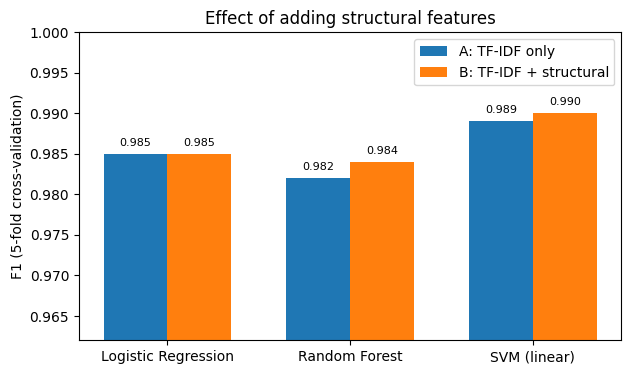

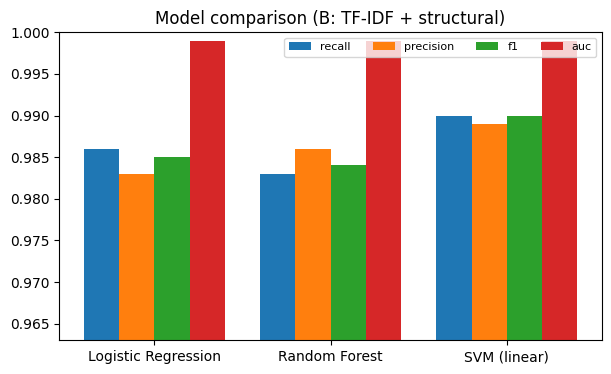

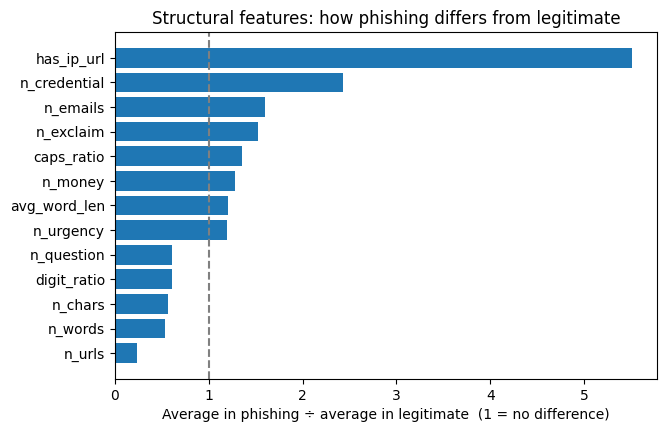

In [11]:
# Figures for the write-up
# Three charts, saved to the Results folder:
#   1. F1 for each model, TF-IDF only vs TF-IDF + structural
#   2. Recall, precision and AUC for the chosen feature set, by model
#   3. Structural features, average value for phishing vs legitimate

results_folder = os.path.join(project, "Results")
os.makedirs(results_folder, exist_ok=True)
import matplotlib.pyplot as plt

res = pd.read_csv(os.path.join(data_folder, "table_cv_results.csv"))
model_names = list(models.keys())
fs_names = list(feature_sets.keys())
chosen_feature_set = "B: TF-IDF + structural"

# --- Figure 1: does adding structural features help? ---
plt.figure(figsize=(7, 4))
width = 0.35
xs = np.arange(len(model_names))
for i, fs in enumerate(fs_names):
    vals = [res[(res["feature_set"] == fs) & (res["model"] == m)]["f1"].values[0] for m in model_names]
    plt.bar(xs + (i - 0.5) * width, vals, width, label=fs)
    for x, v in zip(xs + (i - 0.5) * width, vals):
        plt.text(x, v + 0.001, f"{v:.3f}", ha="center", fontsize=8)
plt.xticks(xs, model_names)
plt.ylabel("F1 (5-fold cross-validation)")
plt.ylim(min(res["f1"]) - 0.02, 1.0)
plt.title("Effect of adding structural features")
plt.legend()
plt.savefig(os.path.join(results_folder, "fig_cv_feature_sets.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: all metrics for the chosen feature set ---
sub = res[res["feature_set"] == chosen_feature_set].set_index("model").loc[model_names]
plt.figure(figsize=(7, 4))
metrics = ["recall", "precision", "f1", "auc"]
width = 0.2
for i, m in enumerate(metrics):
    plt.bar(xs + (i - 1.5) * width, sub[m], width, label=m)
plt.xticks(xs, model_names)
plt.ylim(min(sub[metrics].min()) - 0.02, 1.0)
plt.title(f"Model comparison ({chosen_feature_set})")
plt.legend(ncol=4, fontsize=8)
plt.savefig(os.path.join(results_folder, "fig_cv_models.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 3: structural features, phishing vs legitimate ---
means = X[features.STRUCTURAL_COLUMNS].groupby(y).mean()
ratio = (means.loc[1] / means.loc[0].replace(0, np.nan)).sort_values()
plt.figure(figsize=(7, 4.5))
plt.barh(ratio.index, ratio.values)
plt.axvline(1, color="grey", linestyle="--")
plt.xlabel("Average in phishing ÷ average in legitimate  (1 = no difference)")
plt.title("Structural features: how phishing differs from legitimate")
plt.savefig(os.path.join(results_folder, "fig_structural_features.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Quick sanity check on a few made-up emails by Claude
import joblib
final_model = joblib.load(os.path.join(model_folder, "phishing_model.joblib"))

examples = [
    "URGENT: Your school email account will be suspended in 24 hours. Click here to verify your password: http://login-secure-portal.xyz",
    "Hi all, reminder that the Year 9 parents' evening is on Thursday from 4pm in the main hall. Please sign up on the sheet in the staffroom.",
    "Dear staff member, payroll has been unable to process your salary. Confirm your bank details at the link below to avoid delay.",
    "Attached are the minutes from Monday's SLT meeting. Let me know if I've missed anything.",
]
probs = final_model.predict_proba(features.make_frame(examples))[:, 1]
for text, p in zip(examples, probs):
    print(f"{p*100:5.1f}% phishing | {text[:80]}...")

100.0% phishing | URGENT: Your school email account will be suspended in 24 hours. Click here to v...
 31.5% phishing | Hi all, reminder that the Year 9 parents' evening is on Thursday from 4pm in the...
 98.9% phishing | Dear staff member, payroll has been unable to process your salary. Confirm your ...
  0.2% phishing | Attached are the minutes from Monday's SLT meeting. Let me know if I've missed a...


In [14]:
# Save the model
# joblib saves the whole pipeline (TF-IDF + scaler + model + calibration) in one file. The tool loads this file and features.py, and nothing else.

import joblib

joblib.dump(final_model, os.path.join(model_folder, "phishing_model.joblib"))
with open(os.path.join(model_folder, "model_info.txt"), "w") as f:
    f.write(f"feature_set: {chosen_feature_set}\nmodel: {chosen_model}\n"
            f"trained_on: phishing_general_clean.csv ({len(X)} rows)\n"
            f"cv_f1: {best['f1']:.3f}\ncv_recall: {best['recall']:.3f}\ncv_auc: {best['auc']:.3f}\n")
print("Saved -> Model/phishing_model.joblib and Model/model_info.txt")

NameError: name 'chosen_model' is not defined

In [15]:
# Check all is saved

print(os.listdir(model_folder))
print(open(os.path.join(model_folder, "model_info.txt")).read())

['features.py', '__pycache__', 'phishing_model.joblib', 'model_info.txt']

